# 🧭**MeridianIQ**

## *Hybrid Clause Extraction and LLM Orchestration for Contract Risk Intelligence*

MeridianIQ is an end-to-end AI-powered contract intelligence system designed to assist in the automated review of commercial contracts. It combines hybrid clause detection, semantic evidence retrieval, business-oriented risk scoring, and Large Language Model (LLM) orchestration to transform lengthy legal agreements into structured, explainable, and actionable contract intelligence.

Rather than relying solely on generative AI, MeridianIQ follows a hybrid architecture where deterministic machine learning models, rule-based decision intelligence, semantic retrieval, and LLM-generated summaries work together to improve transparency and reduce hallucinations during contract review.

### Notebook 01: Data Understanding

This notebook focuses on understanding the CUAD dataset before building any machine learning models. We explore the overall dataset structure, identify different categories of contract information, examine clause distributions, analyse missing values, and study the characteristics of legal clauses that will later form the foundation of MeridianIQ's clause detection and risk intelligence pipeline.

# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)
pd.set_option("display.max_colwidth",100)

## Loading the CUAD Dataset

The first step in any machine learning project is understanding the available data. Before designing models or defining business logic, it is important to inspect the dataset structure and verify that it has been loaded correctly.

In this section, we load the CUAD (Contract Understanding Atticus Dataset), which contains manually annotated commercial contracts along with expert-labelled clause information. These annotations will later serve as the foundation for clause detection, semantic retrieval, and contract risk analysis throughout MeridianIQ.

In [ ]:
df=pd.read_csv("master_clauses.csv")
df.shape

(510, 83)

# Initial Dataset Preview

In [ ]:
df.head(2)

,Filename,Document Name,Document Name-Answer,Parties,Parties-Answer,Agreement Date,Agreement Date-Answer,Effective Date,Effective Date-Answer,Expiration Date,Expiration Date-Answer,Renewal Term,Renewal Term-Answer,Notice Period To Terminate Renewal,Notice Period To Terminate Renewal- Answer,Governing Law,Governing Law-Answer,Most Favored Nation,Most Favored Nation-Answer,Competitive Restriction Exception,Competitive Restriction Exception-Answer,Non-Compete,Non-Compete-Answer,Exclusivity,Exclusivity-Answer,No-Solicit Of Customers,No-Solicit Of Customers-Answer,No-Solicit Of Employees,No-Solicit Of Employees-Answer,Non-Disparagement,Non-Disparagement-Answer,Termination For Convenience,Termination For Convenience-Answer,Rofr/Rofo/Rofn,Rofr/Rofo/Rofn-Answer,Change Of Control,Change Of Control-Answer,Anti-Assignment,Anti-Assignment-Answer,Revenue/Profit Sharing,Revenue/Profit Sharing-Answer,Price Restrictions,Price Restrictions-Answer,Minimum Commitment,Minimum Commitment-Answer,Volume Restriction,Volume Restriction-Answer,Ip Ownership Assignment,Ip Ownership Assignment-Answer,Joint Ip Ownership,Joint Ip Ownership-Answer,License Grant,License Grant-Answer,Non-Transferable License,Non-Transferable License-Answer,Affiliate License-Licensor,Affiliate License-Licensor-Answer,Affiliate License-Licensee,Affiliate License-Licensee-Answer,Unlimited/All-You-Can-Eat-License,Unlimited/All-You-Can-Eat-License-Answer,Irrevocable Or Perpetual License,Irrevocable Or Perpetual License-Answer,Source Code Escrow,Source Code Escrow-Answer,Post-Termination Services,Post-Termination Services-Answer,Audit Rights,Audit Rights-Answer,Uncapped Liability,Uncapped Liability-Answer,Cap On Liability,Cap On Liability-Answer,Liquidated Damages,Liquidated Damages-Answer,Warranty Duration,Warranty Duration-Answer,Insurance,Insurance-Answer,Covenant Not To Sue,Covenant Not To Sue-Answer,Third Party Beneficiary,Third Party Beneficiary-Answer
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_EX-10.27_Affiliate Agreement.pdf,['MARKETING AFFILIATE AGREEMENT'],MARKETING AFFILIATE AGREEMENT,"['BIRCH FIRST GLOBAL INVESTMENTS INC.', 'MA', 'Marketing Affiliate', 'MOUNT KNOWLEDGE HOLDINGS I...","Birch First Global Investments Inc. (""Company""); Mount Kowledge Holdings Inc. (""Marketing Affili...","['8th day of May 2014', 'May 8, 2014']",5/8/14,['This agreement shall begin upon the date of its execution by MA and acceptance in writing by C...,NaN,['This agreement shall begin upon the date of its execution by MA and acceptance in writing by C...,12/31/14,['This agreement shall begin upon the date of its execution by MA and acceptance in writing by C...,successive 1 year,['This Agreement may be terminated by either party at the expiration of its term or any renewal ...,30 days,['This Agreement is accepted by Company in the State of Nevada and shall be governed by and cons...,Nevada,[],No,[],No,[],No,[],No,[],No,[],No,"['Company shall not specify the business practices of MA, nor regulate the manner in which MA sh...",Yes,[],No,[],No,[],No,"['MA may not assign, sell, lease or otherwise transfer in whole or in party any of the rights gr...",Yes,[],No,[],No,['INITIAL ORDER COMMITMENT - MA commits to purchase a minimum of 100 Units in aggregate within t...,Yes,[],No,[],No,[],No,"['Company hereby grants MA, during the term of this Agreement, the right to use Company and/or C...",Yes,[],No,[],No,[],No,[],No,[],No,[],No,[],No,"['MA shall keep accurate records of the sales of the Technology and Maintenance, including Clien...",Yes,[],No,['The foregoing states the entire liability of Company with respect to infringement of intellect...,Yes,[],No,"[""COMPANY'S SOLE AND EXCLUSIVE LIABILITY FOR THE WARRANTY PROVIDED IN SUBPARAGRAH (A) HEREOF SHA...",Yes,[],No,[],No,[],No
1,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B(01)_525118_EX-10.B(01)_Content License Agreement.pdf,['VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT'],VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT,"['EuroMedia Holdings Corp.',

# Inspecting Dataset Columns

In [ ]:
df.columns.to_list()[:20]


['Filename',
 'Document Name',
 'Document Name-Answer',
 'Parties',
 'Parties-Answer',
 'Agreement Date',
 'Agreement Date-Answer',
 'Effective Date',
 'Effective Date-Answer',
 'Expiration Date',
 'Expiration Date-Answer',
 'Renewal Term',
 'Renewal Term-Answer',
 'Notice Period To Terminate Renewal',
 'Notice Period To Terminate Renewal- Answer',
 'Governing Law',
 'Governing Law-Answer',
 'Most Favored Nation',
 'Most Favored Nation-Answer',
 'Competitive Restriction Exception']

# Examining Dataset Structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 83 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Filename                                    510 non-null    object
 1   Document Name                               510 non-null    object
 2   Document Name-Answer                        510 non-null    object
 3   Parties                                     510 non-null    object
 4   Parties-Answer                              509 non-null    object
 5   Agreement Date                              510 non-null    object
 6   Agreement Date-Answer                       465 non-null    object
 7   Effective Date                              510 non-null    object
 8   Effective Date-Answer                       359 non-null    object
 9   Expiration Date                             510 non-null    object
 10  Expiration Date-Answer    

##Separating Context Columns and Answer Columns

CUAD contains two major types of columns.
Context columns contain the actual extracted clause text, while answer columns contain the structured label or answer for that clause.

This separation is important because MeridianIQ will later use context columns for evidence and answer columns for structured contract intelligence.

In [ ]:
filename_col="Filename"

answer_cols=[col for col in df.columns if "Answer" in col]
context_cols=[col for col in df.columns if col not in answer_cols+[filename_col]]

len(answer_cols),len(context_cols)

(41, 41)

# Previewing Context Columns

In [ ]:
context_cols[:10]

['Document Name',
 'Parties',
 'Agreement Date',
 'Effective Date',
 'Expiration Date',
 'Renewal Term',
 'Notice Period To Terminate Renewal',
 'Governing Law',
 'Most Favored Nation',
 'Competitive Restriction Exception']

# Previewing Answer Columns

In [ ]:
answer_cols[:10]

['Document Name-Answer',
 'Parties-Answer',
 'Agreement Date-Answer',
 'Effective Date-Answer',
 'Expiration Date-Answer',
 'Renewal Term-Answer',
 'Notice Period To Terminate Renewal- Answer',
 'Governing Law-Answer',
 'Most Favored Nation-Answer',
 'Competitive Restriction Exception-Answer']

#Creating a Clause Summary Table

This step creates a simple mapping between each clause, its context column, and its answer column.
This gives us a clearer view of how CUAD organizes clause-level information and helps us confirm that each clause has both evidence and an answer.

In [ ]:
clause_summary=pd.DataFrame({
    "clause": context_cols,
    "context_column": context_cols,
    "answer_column": answer_cols
})

clause_summary.head(10)

,clause,context_column,answer_column
0,Document Name,Document Name,Document Name-Answer
1,Parties,Parties,Parties-Answer
2,Agreement Date,Agreement Date,Agreement Date-Answer
3,Effective Date,Effective Date,Effective Date-Answer
4,Expiration Date,Expiration Date,Expiration Date-Answer
5,Renewal Term,Renewal Term,Renewal Term-Answer
6,Notice Period To Terminate Renewal,Notice Period To Terminate Renewal,Notice Period To Terminate Renewal- Answer
7,Governing Law,Governing Law,Governing Law-Answer
8,Most Favored Nation,Most Favored Nation,Most Favored Nation-Answer
9,Competitive Restriction Exception,Competitive Restriction Exception,Competitive Restriction Exception-Answer


#Identifying Yes/No Clause Columns

Many CUAD answer columns are binary, meaning they contain only Yes or No.
These binary fields are important because they represent whether a legal clause exists in a contract.

In [ ]:
yes_no_cols=[]

for col in answer_cols:
  unique_values=set(df[col].dropna().astype(str).str.strip().unique())
  if unique_values.issubset({"Yes","No"}):
    yes_no_cols.append(col)

len(yes_no_cols)

33

##Calculating Clause Presence Rates

This cell calculates how frequently each binary clause appears across the 510 contracts.
This is important because clause frequency helps us understand imbalance in the dataset.

For example, common clauses may be easier to detect, while rare clauses may be harder to model and may require special handling during evaluation.

In [ ]:
presence_counts=[]

for col in yes_no_cols:
  clause_name= col.replace("-Answer","").replace("- Answer","")
  yes_count=(df[col].astype(str).str.strip()=="Yes").sum()
  no_count=(df[col].astype(str).str.strip()=="No").sum()

  presence_counts.append({
      "clause": clause_name,
      "yes_count": yes_count,
      "no_count": no_count,
      "presence_rate": yes_count/len(df)
  })

presence_df=pd.DataFrame(presence_counts).sort_values(
    by= "presence_rate",
    ascending=False
)

presence_df


,clause,yes_count,no_count,presence_rate
10,Anti-Assignment,374,136,0.733333
27,Cap On Liability,275,235,0.539216
17,License Grant,255,255,0.500000
25,Audit Rights,214,296,0.419608
7,Termination For Convenience,183,327,0.358824
24,Post-Termination Services,182,328,0.356863
3,Exclusivity,180,330,0.352941
30,Insurance,167,343,0.327451
11,Revenue/Profit Sharing,166,344,0.325490
13,Minimum Commitment,165,345,0.323529


##Identifying Binary and Entity Fields

Not all answer columns are simple Yes/No labels.
Some columns contain metadata or extracted values such as document names, parties, dates, renewal terms, notice periods, and governing law.

This step automatically separates binary clause fields from entity-style fields

In [ ]:
binary_cols=[]
entity_cols=[]

for col in answer_cols:

  values=(df[col].dropna().astype(str).str.strip().unique())

  value_set=set(values)

  if value_set.issubset({"Yes","No"}):
    binary_cols.append(col)
  else:
    entity_cols.append(col)

print("Binary Columns: ",len(binary_cols))
print("Entity Columns: ",len(entity_cols))

Binary Columns:  33
Entity Columns:  8


##Building Clause Metadata

This cell creates a metadata table showing whether each answer column is binary or entity-based.

In [ ]:
clause_metadata=pd.DataFrame({
    "answer column":answer_cols,
    "answer_type":[
        "binary" if col in binary_cols
         else "entity" for col in answer_cols
    ]

})

clause_metadata

,answer column,answer_type
0,Document Name-Answer,entity
1,Parties-Answer,entity
2,Agreement Date-Answer,entity
3,Effective Date-Answer,entity
4,Expiration Date-Answer,entity
5,Renewal Term-Answer,entity
6,Notice Period To Terminate Renewal- Answer,entity
7,Governing Law-Answer,entity
8,Most Favored Nation-Answer,binary
9,Competitive Restriction Exception-Answer,binary


# Inspecting Entity Fields



In [ ]:
for col in entity_cols:
  print("\n",col)
  print(df[col].dropna().head(10).to_list())


 Document Name-Answer
['MARKETING AFFILIATE AGREEMENT', 'VIDEO-ON-DEMAND CONTENT LICENSE AGREEMENT', 'CONTENT DISTRIBUTION AND LICENSE AGREEMENT', 'WEBSITE CONTENT LICENSE AGREEMENT', 'CONTENT LICENSE AGREEMENT', 'CO-BRANDING AND SERVICES AGREEMENT', 'CO-BRANDING AGREEMENT', 'PRODUCT DEVELOPMENT AND CO-BRANDING AGREEMENT', 'ENDORSEMENT LICENSING AND CO-BRANDING AGREEMENT', 'CO-BRANDING AGREEMENT']

 Parties-Answer
['Birch First Global Investments Inc. ("Company"); Mount Kowledge Holdings Inc. ("Marketing Affiliate", "MA")', 'Rogers Cable Communications Inc. ("Rogers"); EuroMedia Holdings Corp. ("Licensor")', 'CONVERGTV,\xa0INC.\xa0(“ConvergTV”); Fulucai Productions Ltd. ("Producer")', 'PSiTech Corporation ("Licensor"); Empirical Ventures, Inc ("Licensee")', 'Beijing Sun Seven Stars Culture Development Limited ("Licensor"); YOU ON DEMAND HOLDINGS, INC ("Licensee")', 'RSL COM PrimeCall, Inc. ("PrimeCall"); deltathree.com, Inc. (formerly known as Delta Three, Inc.) ("DeltaThree")', 'WOME

#Entity Field Missingness Summary

This step measures how often each entity field is missing.
Missing values in legal contracts are not always data quality problems.

For example, a missing renewal term may simply mean that the contract does not contain a renewal clause.
This distinction matters because MeridianIQ should treat some missing values as meaningful contract structure signals rather than errors.

In [ ]:
entity_summary=pd.DataFrame({
    "column":entity_cols,
    "non_null":[df[col].notna().sum() for col in entity_cols],
    "missing":[df[col].isna().sum() for col in entity_cols],
    "missing_pct":[
        round(df[col].isna().mean()*100,2)
        for col in entity_cols
    ]
})

entity_summary

,column,non_null,missing,missing_pct
0,Document Name-Answer,510,0,0.00
1,Parties-Answer,509,1,0.20
2,Agreement Date-Answer,465,45,8.82
3,Effective Date-Answer,359,151,29.61
4,Expiration Date-Answer,329,181,35.49
5,Renewal Term-Answer,163,347,68.04
6,Notice Period To Terminate Renewal- Answer,101,409,80.20
7,Governing Law-Answer,434,76,14.90


# Visualizing Entity Missingness

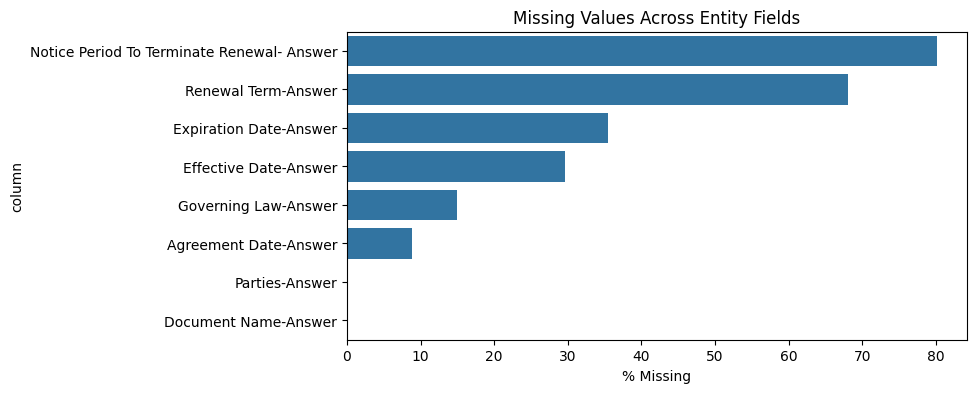

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=entity_summary.sort_values(
        by="missing_pct",
        ascending=False
    ),
    x="missing_pct",
    y="column"
)

plt.title("Missing Values Across Entity Fields")
plt.xlabel("% Missing")
plt.show()

# Visualizing Clause Presence Distribution

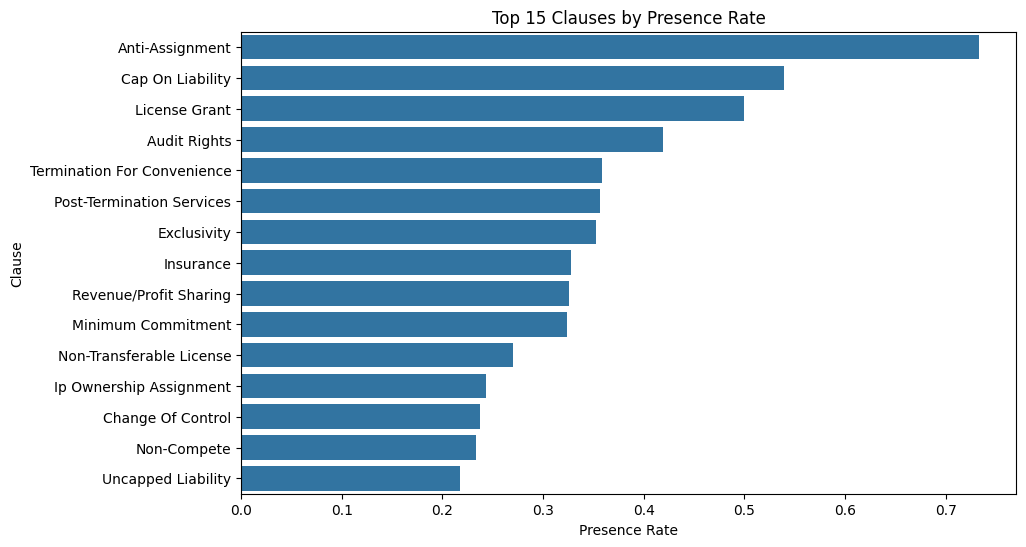

In [ ]:
top15_clauses=presence_df.head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top15_clauses,
    x="presence_rate",
    y="clause"
)

plt.title("Top 15 Clauses by Presence Rate")
plt.xlabel("Presence Rate")
plt.ylabel("Clause")
plt.show()

# Contract Type Distribution

In [ ]:
contract_types=(
    df["Document Name-Answer"]
    .astype(str)
    .value_counts()
)
contract_types.head(20)

,count
Document Name-Answer,
SPONSORSHIP AGREEMENT,20
STRATEGIC ALLIANCE AGREEMENT,16
ENDORSEMENT AGREEMENT,14
JOINT FILING AGREEMENT,12
AGENCY AGREEMENT,12
Strategic Alliance Agreement,12
CO-BRANDING AGREEMENT,12
DISTRIBUTOR AGREEMENT,12
CONSULTING AGREEMENT,10


# Correlation Between Binary Clauses

In [ ]:
binary_df=df[yes_no_cols].replace({
    "Yes":1,
    "No":0
})

corr=binary_df.corr()

corr_pairs=(
    corr.where(~np.eye(corr.shape[0],dtype=bool))
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs.head(20)

/tmp/ipykernel_2038/3077026104.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_df=df[yes_no_cols].replace({


,,0
License Grant-Answer,Non-Transferable License-Answer,0.591417
Non-Transferable License-Answer,License Grant-Answer,0.591417
Cap On Liability-Answer,Uncapped Liability-Answer,0.487576
Uncapped Liability-Answer,Cap On Liability-Answer,0.487576
Affiliate License-Licensee-Answer,Affiliate License-Licensor-Answer,0.423597
Affiliate License-Licensor-Answer,Affiliate License-Licensee-Answer,0.423597
Audit Rights-Answer,Cap On Liability-Answer,0.411370
Cap On Liability-Answer,Audit Rights-Answer,0.411370
Post-Termination Services-Answer,Audit Rights-Answer,0.403331
Audit Rights-Answer,Post-Termination Services-Answer,0.403331


##Key findings:

- CUAD contains 510 commercial contracts and 41 legal clause categories.
- Clauses consist of 33 binary categories and 8 metadata/entity fields.
- Clause distributions are highly imbalanced.
- Metadata fields naturally form a Contract Fingerprint.
- Clauses can be grouped into business-oriented risk domains.
- Missing values are largely structural and often indicate clause absence rather than poor data quality.

These findings establish the foundation for MeridianIQ's Contract Fingerprint, Risk Engine, and Intelligence Layer.